# Convolutional Blocks of ResNet18

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torchvision.models as models
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import f1_score, confusion_matrix
import torchvision.transforms as transforms
from PIL import Image
import wandb

In [2]:
wandb.login(key="7ee7d9afbe512d70fe46f3edcd704e4160629dd8")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: shravya1051. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [3]:
train_data = torch.load('/kaggle/input/q1-data/train_data.pt', weights_only=True)
train_labels = torch.load('/kaggle/input/q1-data/train_labels.pt', weights_only=True)

test_data = torch.load('/kaggle/input/q1-data/test_data.pt', weights_only=True)
test_labels = torch.load('/kaggle/input/q1-data/test_labels.pt', weights_only=True)

print(train_data.shape)
print(train_labels.shape)

torch.Size([50000, 3, 36, 36])
torch.Size([50000])


[0 1 2 3 4 5 6 7 8 9]


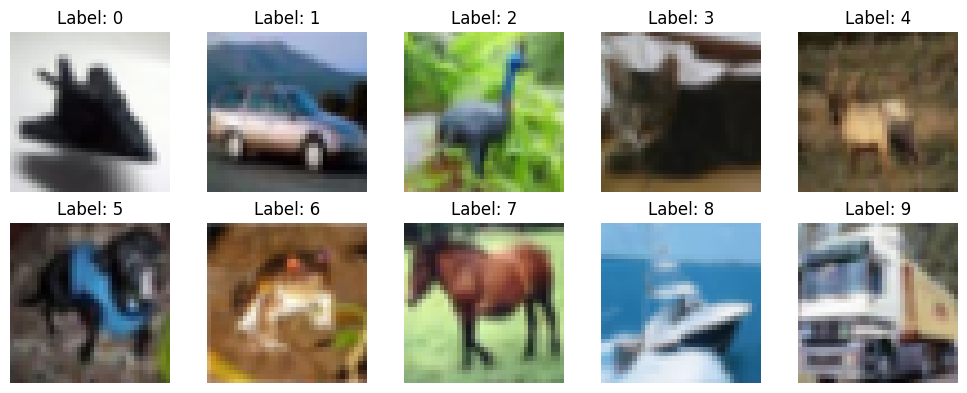

In [4]:
unique_labels = np.unique(train_labels)
print(unique_labels)

def display_images_for_labels(data, labels, unique_labels):
    plt.figure(figsize=(10, 4))
    for i, label in enumerate(unique_labels[:10]):
        idx = np.where(labels == label)[0][0]
        image = data[idx]

        image = image.permute(1, 2, 0).numpy()

        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_images_for_labels(train_data, train_labels, unique_labels)

## 1.1 Baseline - Training ResNet

In [5]:
train_data = train_data.clone().detach().to(torch.float32)
train_labels = train_labels.clone().detach().to(torch.long)
test_data = test_data.clone().detach().to(torch.float32)
test_labels = test_labels.clone().detach().to(torch.long)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def transform_batch(batch_data):
    transformed_images = []

    for image in batch_data:
        image = image.mul(255).byte()  
        pil_image = Image.fromarray(image.permute(1, 2, 0).cpu().numpy())  # Convert to HWC format

        transformed_image = transform(pil_image)
        transformed_images.append(transformed_image)

    return torch.stack(transformed_images)

In [ ]:
def train_model(project, model_name, model, train_loader, test_loader, num_epochs=5, learning_rate=0.001, resize=False):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    wandb.init(project=project, name=model_name, reinit=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            if resize:
                inputs = transform_batch(inputs)
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                if resize:
                    inputs = transform_batch(inputs)
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss /= len(test_loader)
        test_acc = 100.0 * correct / total
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

        test_losses.append(test_loss)
        test_accuracies.append(test_acc)

        wandb.log({
            'Train_loss': train_loss, 
            'Test_loss': test_loss, 
            'Train_acc': train_acc, 
            'Test_acc': test_acc, 
            'Epoch': epoch + 1
        })

    wandb.finish()
    return train_losses, test_losses, train_accuracies, test_accuracies, model

### Training Baseline

In [8]:
resnet18 = models.resnet18(weights=None)
train_losses, test_losses, train_accuracies, test_accuracies, resnet18 = train_model("resnet_18", "resnet18",resnet18, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_171227-gzx1laki
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet18
wandb: ⭐️ View project at https://wandb.ai/shravya1051/resnet_18
wandb: 🚀 View run at https://wandb.ai/shravya1051/resnet_18/runs/gzx1laki


Epoch [1/5], Loss: 1.3255, Accuracy: 52.84%
Test Loss: 1.3733, Test Accuracy: 52.23%
Epoch [2/5], Loss: 0.9240, Accuracy: 67.48%
Test Loss: 1.2125, Test Accuracy: 58.17%
Epoch [3/5], Loss: 0.7497, Accuracy: 73.74%
Test Loss: 1.1070, Test Accuracy: 63.66%
Epoch [4/5], Loss: 0.6284, Accuracy: 77.95%
Test Loss: 0.8375, Test Accuracy: 72.07%
Epoch [5/5], Loss: 0.5128, Accuracy: 81.89%
Test Loss: 0.7507, Test Accuracy: 74.60%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▃▅▇█
wandb:  Test_loss █▆▅▂▁
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▅▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 74.6
wandb:  Test_loss 0.75066
wandb:  Train_acc 81.894
wandb: Train_loss 0.51285
wandb: 
wandb: 🚀 View run resnet18 at: https://wandb.ai/shravya1051/resnet_18/runs/gzx1laki
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/resnet_18
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_171227-gzx1laki/logs


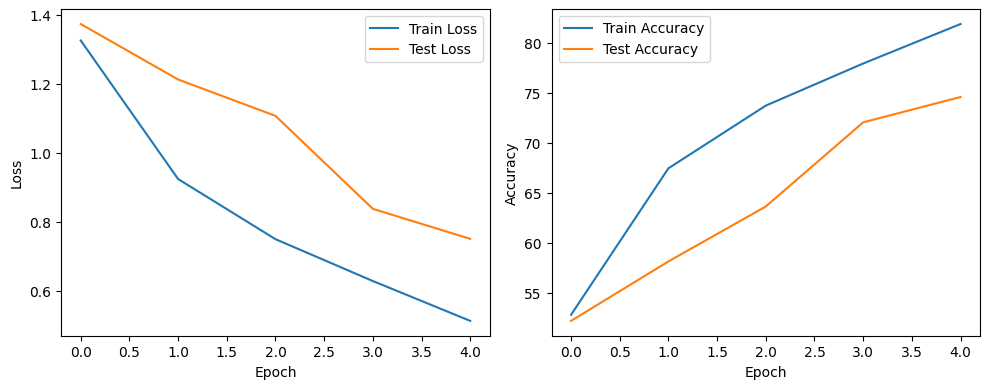

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
torch.save(resnet18, 'resnet18.pt')

In [11]:
def compute_f1_score(model, test_loader, resize=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            if resize:
                inputs = transform_batch(inputs)
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    f1 = f1_score(all_targets, all_predictions, average='macro')
    cm = confusion_matrix(all_targets, all_predictions)

    return f1, cm

F1 Score: 0.7469070303729001


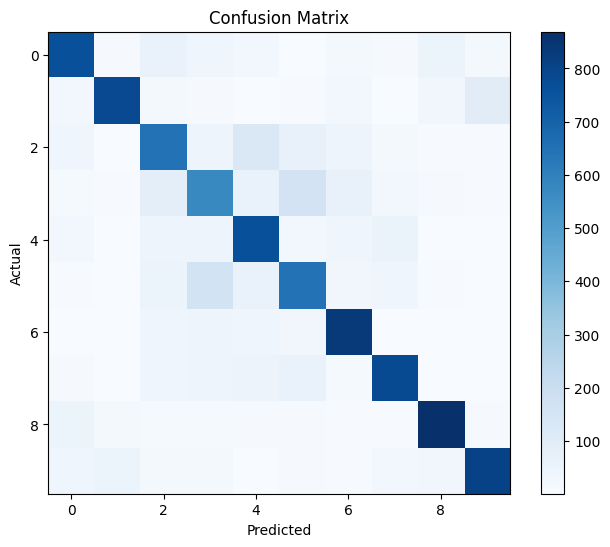

In [12]:
f1, cm = compute_f1_score(resnet18, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Training the pretrained model

In [13]:
pretrained_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_classes = 10
pretrained_resnet18.fc = nn.Linear(pretrained_resnet18.fc.in_features, num_classes)
train_losses, test_losses, train_accuracies, test_accuracies, pretrained_resnet18 = train_model("pretrained_resnet_18","pretrainedresnet18",pretrained_resnet18, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 82.1MB/s]
wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_171323-f5jas4uo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pretrainedresnet18
wandb: ⭐️ View project at https://wandb.ai/shravya1051/pretrained_resnet_18
wandb: 🚀 View run at https://wandb.ai/shravya1051/pretrained_resnet_18/runs/f5jas4uo


Epoch [1/5], Loss: 0.8105, Accuracy: 72.73%
Test Loss: 0.8095, Test Accuracy: 72.43%
Epoch [2/5], Loss: 0.5274, Accuracy: 82.37%
Test Loss: 0.6844, Test Accuracy: 76.96%
Epoch [3/5], Loss: 0.3952, Accuracy: 86.50%
Test Loss: 0.6399, Test Accuracy: 79.36%
Epoch [4/5], Loss: 0.3060, Accuracy: 89.65%
Test Loss: 0.7396, Test Accuracy: 76.68%
Epoch [5/5], Loss: 0.2388, Accuracy: 91.83%
Test Loss: 0.6802, Test Accuracy: 79.79%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▅█▅█
wandb:  Test_loss █▃▁▅▃
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▅▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 79.79
wandb:  Test_loss 0.68023
wandb:  Train_acc 91.832
wandb: Train_loss 0.23881
wandb: 
wandb: 🚀 View run pretrainedresnet18 at: https://wandb.ai/shravya1051/pretrained_resnet_18/runs/f5jas4uo
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/pretrained_resnet_18
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_171323-f5jas4uo/logs


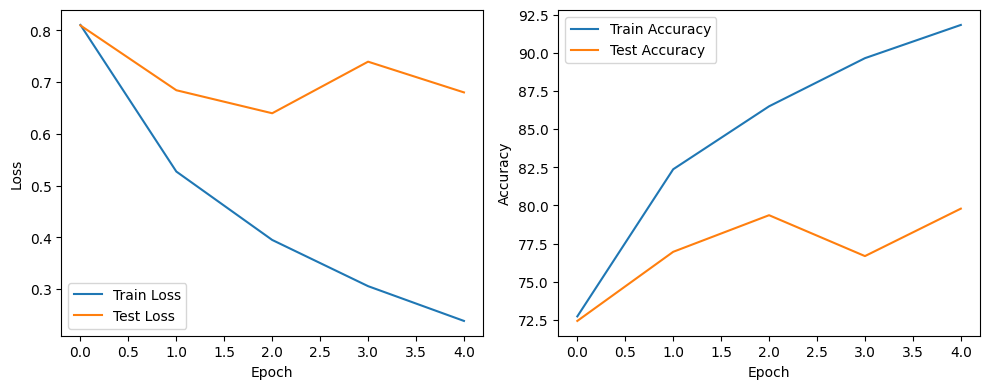

In [14]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
torch.save(pretrained_resnet18, 'pretrained_resnet18.pt')

F1 Score: 0.7995828024722351


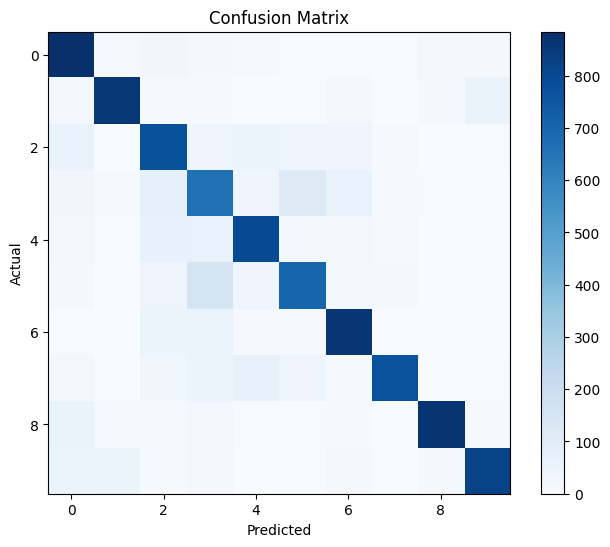

In [16]:
f1, cm = compute_f1_score(pretrained_resnet18, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
x = torch.randn(1, 3, 36, 36)

model = models.resnet18(weights=None)

for name, layer in model.named_children():
    print(f"{name}: {layer}")

conv1: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
bn1: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
relu: ReLU(inplace=True)
maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
layer1: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stri

In [18]:
shapes = []
modules = list(model.named_children())[:-1]

with torch.no_grad():
    for i, (name, layer) in enumerate(modules):
        x = layer(x)
        shapes.append((i, name, x.shape))

for i, name, shape in shapes:
    print(f"Layer {i} ({name}): Output Shape {shape}")

Layer 0 (conv1): Output Shape torch.Size([1, 64, 18, 18])
Layer 1 (bn1): Output Shape torch.Size([1, 64, 18, 18])
Layer 2 (relu): Output Shape torch.Size([1, 64, 18, 18])
Layer 3 (maxpool): Output Shape torch.Size([1, 64, 9, 9])
Layer 4 (layer1): Output Shape torch.Size([1, 64, 9, 9])
Layer 5 (layer2): Output Shape torch.Size([1, 128, 5, 5])
Layer 6 (layer3): Output Shape torch.Size([1, 256, 3, 3])
Layer 7 (layer4): Output Shape torch.Size([1, 512, 2, 2])
Layer 8 (avgpool): Output Shape torch.Size([1, 512, 1, 1])


| **Layer**      | **Operation**                    | **Output Shape (H × W)**  | **Channels**  |
|---------------|----------------------------------|---------------------------|---------------|
| **conv1**      | 7×7 conv, stride 2              | **18 × 18**               | 64            |
| **bn1**        | BatchNorm                       | **18 × 18**               | 64            |
| **relu**       | ReLU activation                 | **18 × 18**               | 64            |
| **maxpool**    | 3×3 max pooling, stride 2       | **9 × 9**                 | 64            |
| **layer1**     | BasicBlock × 2 (stride 1)       | **9 × 9**                 | 64            |
| **layer2**     | BasicBlock × 2 (stride 2)       | **5 × 5**                 | 128           |
| **layer3**     | BasicBlock × 2 (stride 2)       | **3 × 3**                 | 256           |
| **layer4**     | BasicBlock × 2 (stride 2)       | **2 × 2**                 | 512           |
| **avgpool**    | Global Average Pooling (1×1)    | **1 × 1**                 | 512           |


The spatial dimensions just before average pooling are 2×2, and the number of channels is 512.

## 1.2 Training ResNet on resized images

### Training Baseline

In [19]:
resized_resnet18 = models.resnet18(weights=None)
train_losses, test_losses, train_accuracies, test_accuracies, resized_resnet18 = train_model("resized_resnet_18","resizedresnet18",resized_resnet18, train_loader, test_loader, num_epochs=5, learning_rate=0.001, resize=True)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_171417-8tx2jkbw
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resizedresnet18
wandb: ⭐️ View project at https://wandb.ai/shravya1051/resized_resnet_18
wandb: 🚀 View run at https://wandb.ai/shravya1051/resized_resnet_18/runs/8tx2jkbw


Epoch [1/5], Loss: 1.4726, Accuracy: 47.44%
Test Loss: 2.0892, Test Accuracy: 40.13%
Epoch [2/5], Loss: 0.8991, Accuracy: 67.95%
Test Loss: 0.8366, Test Accuracy: 70.93%
Epoch [3/5], Loss: 0.6583, Accuracy: 77.00%
Test Loss: 0.6742, Test Accuracy: 76.64%
Epoch [4/5], Loss: 0.5258, Accuracy: 81.65%
Test Loss: 0.6738, Test Accuracy: 77.22%
Epoch [5/5], Loss: 0.4192, Accuracy: 85.35%
Test Loss: 0.7491, Test Accuracy: 75.55%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▇███
wandb:  Test_loss █▂▁▁▁
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 75.55
wandb:  Test_loss 0.74914
wandb:  Train_acc 85.35
wandb: Train_loss 0.41916
wandb: 
wandb: 🚀 View run resizedresnet18 at: https://wandb.ai/shravya1051/resized_resnet_18/runs/8tx2jkbw
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/resized_resnet_18
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_171417-8tx2jkbw/logs


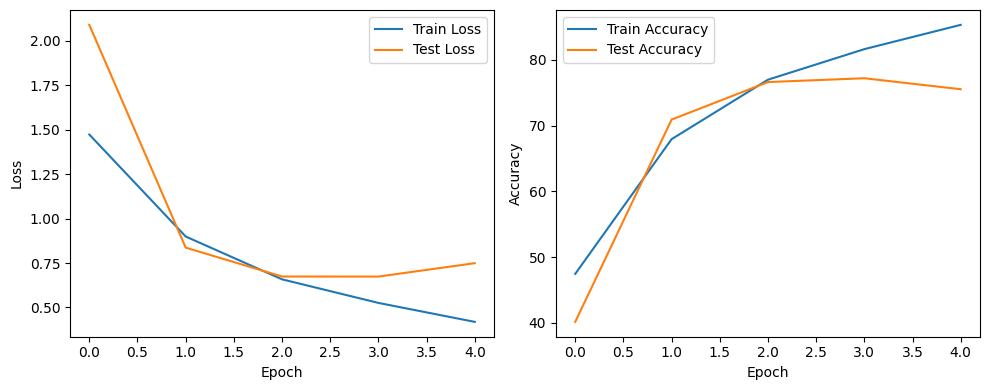

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
torch.save(resized_resnet18, 'resized_resnet18.pt')

F1 Score: 0.7518281736453154


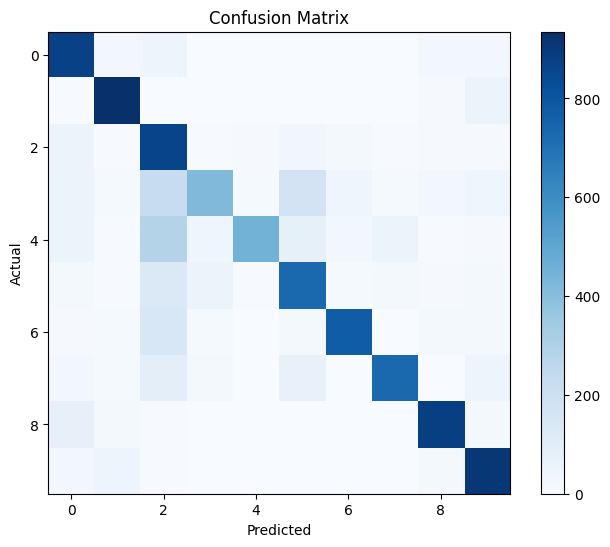

In [22]:
f1, cm = compute_f1_score(resized_resnet18, test_loader, resize=True)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Training the pretrained model

In [23]:
pretrained_resized_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_classes = 10
pretrained_resized_resnet18.fc = nn.Linear(pretrained_resized_resnet18.fc.in_features, num_classes)
train_losses, test_losses, train_accuracies, test_accuracies, pretrained_resized_resnet18 = train_model("pretrained_resized_resnet_18","pretrainedresizedresnet18",pretrained_resized_resnet18, train_loader, test_loader, num_epochs=5, learning_rate=0.001, resize=True)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_172823-7i276610
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pretrainedresizedresnet18
wandb: ⭐️ View project at https://wandb.ai/shravya1051/pretrained_resized_resnet_18
wandb: 🚀 View run at https://wandb.ai/shravya1051/pretrained_resized_resnet_18/runs/7i276610


Epoch [1/5], Loss: 0.5741, Accuracy: 80.33%
Test Loss: 0.4650, Test Accuracy: 83.53%
Epoch [2/5], Loss: 0.3070, Accuracy: 89.43%
Test Loss: 0.4225, Test Accuracy: 85.93%
Epoch [3/5], Loss: 0.2069, Accuracy: 92.85%
Test Loss: 0.3746, Test Accuracy: 87.77%
Epoch [4/5], Loss: 0.1475, Accuracy: 94.83%
Test Loss: 0.3978, Test Accuracy: 87.33%
Epoch [5/5], Loss: 0.1108, Accuracy: 95.99%
Test Loss: 0.3882, Test Accuracy: 88.72%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▄▇▆█
wandb:  Test_loss █▅▁▃▂
wandb:  Train_acc ▁▅▇▇█
wandb: Train_loss █▄▂▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 88.72
wandb:  Test_loss 0.38815
wandb:  Train_acc 95.994
wandb: Train_loss 0.11084
wandb: 
wandb: 🚀 View run pretrainedresizedresnet18 at: https://wandb.ai/shravya1051/pretrained_resized_resnet_18/runs/7i276610
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/pretrained_resized_resnet_18
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_172823-7i276610/logs


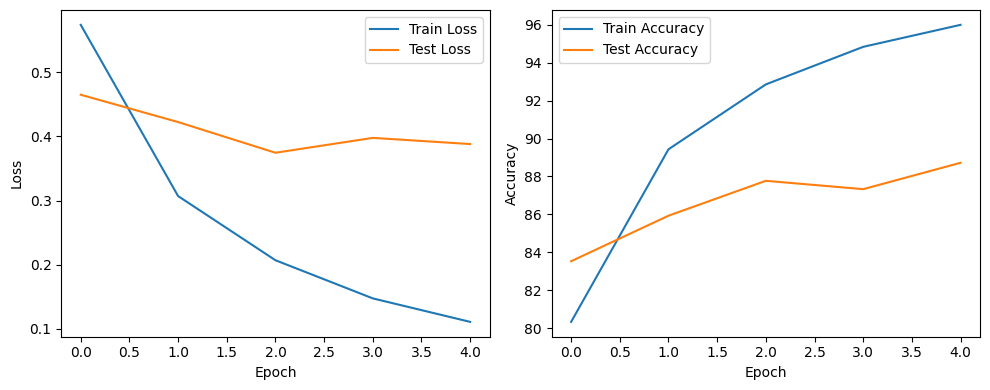

In [24]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
torch.save(pretrained_resized_resnet18, 'pretrained_resized_resnet18.pt')

F1 Score: 0.8872990104233981


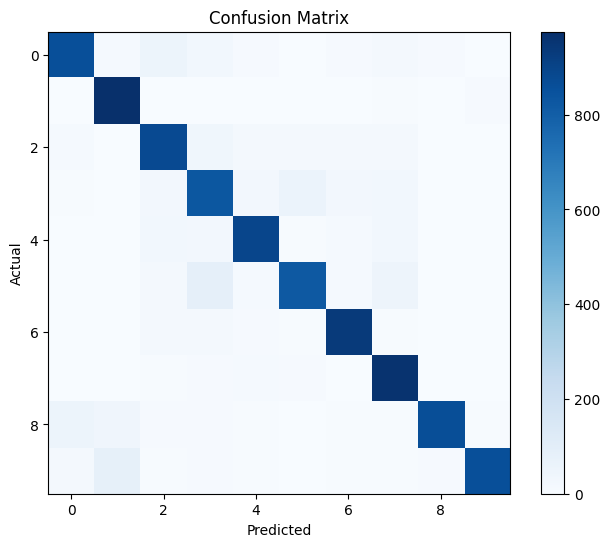

In [26]:
f1, cm = compute_f1_score(pretrained_resized_resnet18, test_loader, resize=True)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

| **Model**                                 | **Input Size** | **F1 Score**        | **Training Time**    | **Memory Usage**    |
|-------------------------------------------|----------------|---------------------|----------------------|---------------------|
| **ResNet18 (Scratch)**                    | 36×36          | 0.7469              | Faster               | Lower               |
| **Pretrained ResNet18**                   | 36×36          | 0.7996              | Faster               | Lower               |
| **ResNet18 (Scratch)**                    | 224×224        | 0.7518              | Slower               | Higher              |
| **Pretrained ResNet18**                   | 224×224        | 0.8873              | Slower               | Higher              |

- **Resizing to 224×224** improves F1 scores due to the **larger spatial dimensions**, allowing the model to capture more detailed features, which is especially beneficial for deeper layers in **pretrained models**.
- **Smaller images (36×36)** have **faster training times and lower memory usage**, but the smaller size limits the amount of information available for the model, resulting in lower F1 scores.
- **Pretraining on ImageNet** helps the model generalize better to new datasets, which is reflected in the **higher F1 score** for the **pretrained ResNet18** on both image sizes.


## Modifying the architecture of ResNet18 to suit the given dataset

### Modifying Initial Layers for Training from Scratch

#### Modification - 1

- Changed conv1 to 3×3 with stride 1 instead of the original 7×7 with stride 2.
- Removed maxpool layer (3×3 with stride 2) to prevent excessive downsampling.
- This modification retains more spatial details by preventing early loss of information, which is especially important for small images (36×36).

In [ ]:
model1 = models.resnet18(weights=None)
model1.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model1.maxpool = nn.Identity()
train_losses, test_losses, train_accuracies, test_accuracies, model1 = train_model("modification_1","modification1",model1, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_174142-d0bry6gq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run modification1
wandb: ⭐️ View project at https://wandb.ai/shravya1051/modification_1
wandb: 🚀 View run at https://wandb.ai/shravya1051/modification_1/runs/d0bry6gq


Epoch [1/5], Loss: 1.2667, Accuracy: 55.16%
Test Loss: 1.1172, Test Accuracy: 61.02%
Epoch [2/5], Loss: 0.7352, Accuracy: 74.19%
Test Loss: 0.7213, Test Accuracy: 75.05%
Epoch [3/5], Loss: 0.5439, Accuracy: 81.12%
Test Loss: 0.6291, Test Accuracy: 78.80%
Epoch [4/5], Loss: 0.4250, Accuracy: 85.20%
Test Loss: 0.6287, Test Accuracy: 78.76%
Epoch [5/5], Loss: 0.3331, Accuracy: 88.43%
Test Loss: 0.5385, Test Accuracy: 82.24%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▆▇▇█
wandb:  Test_loss █▃▂▂▁
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 82.24
wandb:  Test_loss 0.53852
wandb:  Train_acc 88.432
wandb: Train_loss 0.33312
wandb: 
wandb: 🚀 View run modification1 at: https://wandb.ai/shravya1051/modification_1/runs/d0bry6gq
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/modification_1
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_174142-d0bry6gq/logs


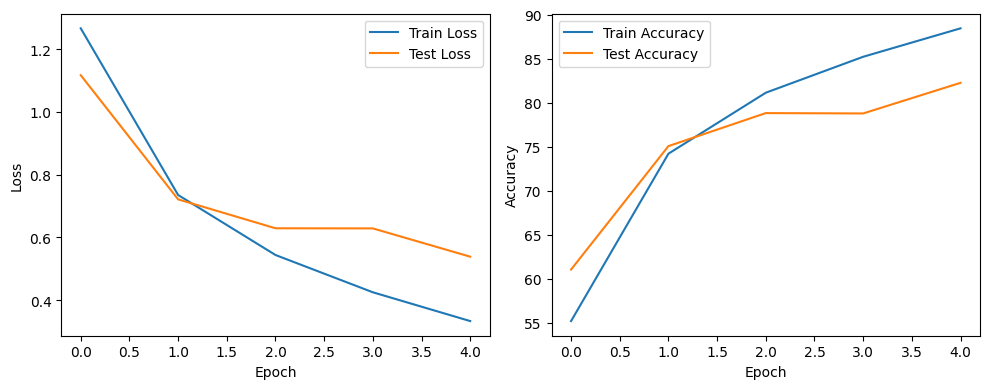

In [28]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.821299143371378


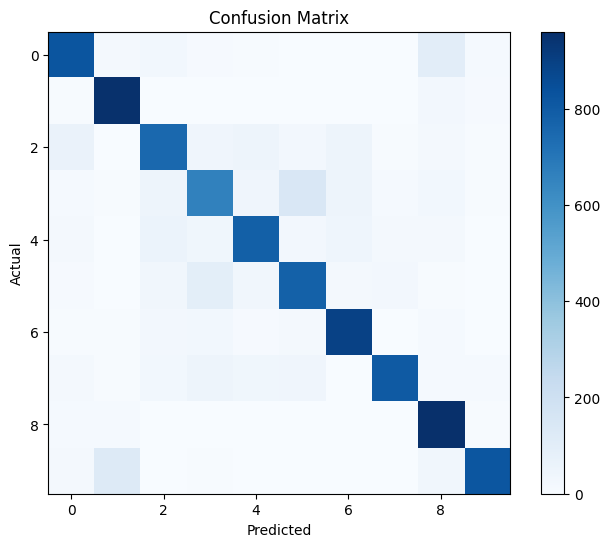

In [29]:
f1, cm = compute_f1_score(model1, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Modification 2

- Modified conv1 to use a 5×5 kernel instead of 7×7, keeping stride 1 to preserve resolution.
- Retained maxpool but reduced its effect by setting kernel size to 2×2 with stride 2.
- A smaller kernel allows the network to extract more localized features, while keeping maxpool ensures some level of downsampling for deeper layers.


In [ ]:
model2 = models.resnet18(weights=None)
model2.conv1 = nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2, bias=False)
model2.maxpool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
train_losses, test_losses, train_accuracies, test_accuracies, model2 = train_model("modification_2","modification2",model2, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_174443-62sby7w0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run modification2
wandb: ⭐️ View project at https://wandb.ai/shravya1051/modification_2
wandb: 🚀 View run at https://wandb.ai/shravya1051/modification_2/runs/62sby7w0


Epoch [1/5], Loss: 1.3164, Accuracy: 53.62%
Test Loss: 2.0116, Test Accuracy: 42.09%
Epoch [2/5], Loss: 0.8477, Accuracy: 70.08%
Test Loss: 1.1079, Test Accuracy: 64.27%
Epoch [3/5], Loss: 0.6520, Accuracy: 77.05%
Test Loss: 0.7074, Test Accuracy: 75.37%
Epoch [4/5], Loss: 0.5045, Accuracy: 82.29%
Test Loss: 0.8451, Test Accuracy: 71.83%
Epoch [5/5], Loss: 0.3887, Accuracy: 86.34%
Test Loss: 0.6899, Test Accuracy: 77.49%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▅█▇█
wandb:  Test_loss █▃▁▂▁
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 77.49
wandb:  Test_loss 0.68995
wandb:  Train_acc 86.344
wandb: Train_loss 0.38871
wandb: 
wandb: 🚀 View run modification2 at: https://wandb.ai/shravya1051/modification_2/runs/62sby7w0
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/modification_2
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_174443-62sby7w0/logs


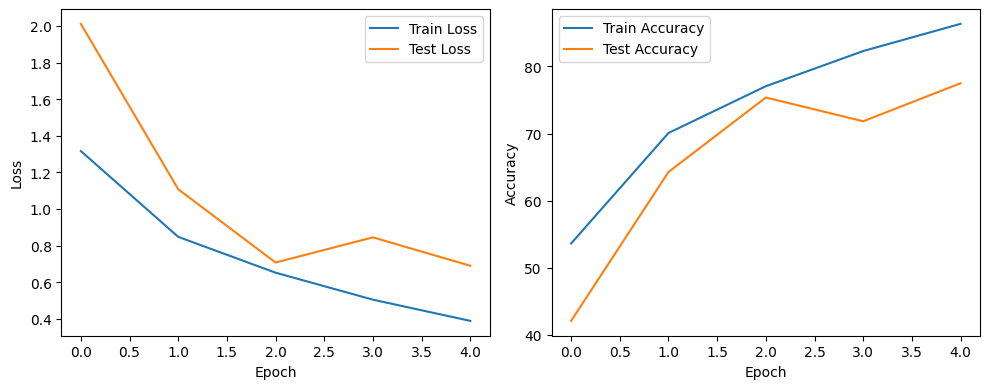

In [31]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.7742528985028474


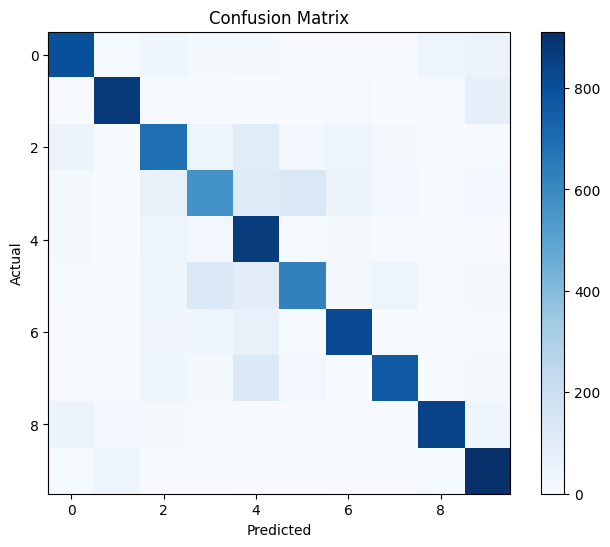

In [32]:
f1, cm = compute_f1_score(model2, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Modification 3

- Replaced the single 7×7 conv with two sequential 3×3 convolutions for better feature extraction.
- Removed maxpool to avoid reducing spatial size too early.
- Two smaller convolutions allow the model to learn more complex patterns while reducing parameters compared to a single large kernel.


In [ ]:
model3 = models.resnet18(weights=None)
model3.conv1 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False)
)
model3.maxpool = nn.Identity()
train_losses, test_losses, train_accuracies, test_accuracies, model3 = train_model("modification_3","modification3",model3, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_174608-dx5pbk6o
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run modification3
wandb: ⭐️ View project at https://wandb.ai/shravya1051/modification_3
wandb: 🚀 View run at https://wandb.ai/shravya1051/modification_3/runs/dx5pbk6o


Epoch [1/5], Loss: 1.3311, Accuracy: 52.48%
Test Loss: 1.1291, Test Accuracy: 59.13%
Epoch [2/5], Loss: 0.7991, Accuracy: 72.04%
Test Loss: 0.8675, Test Accuracy: 70.22%
Epoch [3/5], Loss: 0.5954, Accuracy: 78.98%
Test Loss: 0.7082, Test Accuracy: 75.90%
Epoch [4/5], Loss: 0.4653, Accuracy: 83.74%
Test Loss: 0.5682, Test Accuracy: 80.54%
Epoch [5/5], Loss: 0.3622, Accuracy: 87.37%
Test Loss: 0.6158, Test Accuracy: 79.97%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▅▆██
wandb:  Test_loss █▅▃▁▂
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 79.97
wandb:  Test_loss 0.6158
wandb:  Train_acc 87.37
wandb: Train_loss 0.36219
wandb: 
wandb: 🚀 View run modification3 at: https://wandb.ai/shravya1051/modification_3/runs/dx5pbk6o
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/modification_3
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_174608-dx5pbk6o/logs


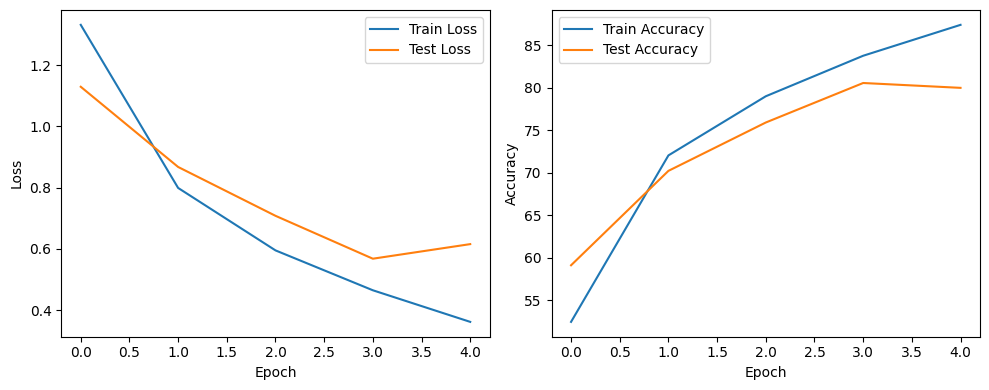

In [34]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.7742528985028474


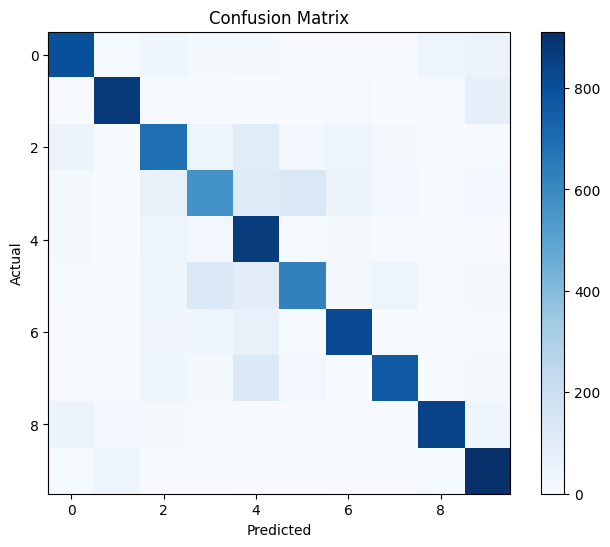

In [35]:
f1, cm = compute_f1_score(model2, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

| **Model**                          | **Input Size** | **F1 Score**        |
|------------------------------------|----------------|---------------------|
| **ResNet18 (Scratch) - 224×224**   | 224×224        | 0.7518              |
| **Modification 1 (Scratch)**       | 36×36          | 0.8213              |
| **Modification 2 (Scratch)**       | 36×36          | 0.7743              |
| **Modification 3 (Scratch)**       | 36×36          | 0.7743              |

- **Modification 1** improves performance significantly with an **F1 score of 0.8213**, outperforming both **ResNet18 trained from scratch on 224×224** and the other two modifications. This suggests that **removing maxpool and reducing stride in `conv1`** preserves more spatial information, leading to better feature extraction.
- **Modification 2 and Modification 3** performed similarly, both achieving an **F1 score of 0.7743**. These modifications focus on **using smaller kernels** and **replacing `conv1` with two `3×3` convolutions**, but they did not show as much improvement as **Modification 1**.
- Overall, **modifying the architecture** for **36×36 images** (instead of resizing to **224×224**) leads to **better performance** while using fewer resources. This highlights that for smaller images, carefully altering the model architecture can lead to **better results than simply increasing input size**.


### Modifying Pretrained ResNet18

#### Modification 1

- Changed `conv1` to **`3×3` with stride `1`** instead of **`7×7` with stride `2`**, preserving more spatial details.  
- **Removed maxpool layer** (`3×3` with stride `2`) to prevent excessive downsampling.  
- Pretrained ResNet18 expects larger images, so this modification ensures **better feature retention** for **36×36** images without losing pretrained knowledge.  

In [ ]:
model_pretrained1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_pretrained1.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_pretrained1.maxpool = nn.Identity()
num_classes = 10
model_pretrained1.fc = nn.Linear(model_pretrained1.fc.in_features, num_classes)
train_losses, test_losses, train_accuracies, test_accuracies, model_pretrained1 = train_model("pretrained_modification_1","pretrainedmodification1",model_pretrained1, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_174914-408r2knl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pretrainedmodification1
wandb: ⭐️ View project at https://wandb.ai/shravya1051/pretrained_modification_1
wandb: 🚀 View run at https://wandb.ai/shravya1051/pretrained_modification_1/runs/408r2knl


Epoch [1/5], Loss: 0.7205, Accuracy: 75.22%
Test Loss: 0.5352, Test Accuracy: 81.82%
Epoch [2/5], Loss: 0.3843, Accuracy: 86.85%
Test Loss: 0.5084, Test Accuracy: 82.98%
Epoch [3/5], Loss: 0.2504, Accuracy: 91.29%
Test Loss: 0.3979, Test Accuracy: 86.98%
Epoch [4/5], Loss: 0.1765, Accuracy: 93.86%
Test Loss: 0.4671, Test Accuracy: 85.94%
Epoch [5/5], Loss: 0.1285, Accuracy: 95.59%
Test Loss: 0.4453, Test Accuracy: 86.64%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▃█▇█
wandb:  Test_loss █▇▁▅▃
wandb:  Train_acc ▁▅▇▇█
wandb: Train_loss █▄▂▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 86.64
wandb:  Test_loss 0.44529
wandb:  Train_acc 95.588
wandb: Train_loss 0.12848
wandb: 
wandb: 🚀 View run pretrainedmodification1 at: https://wandb.ai/shravya1051/pretrained_modification_1/runs/408r2knl
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/pretrained_modification_1
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_174914-408r2knl/logs


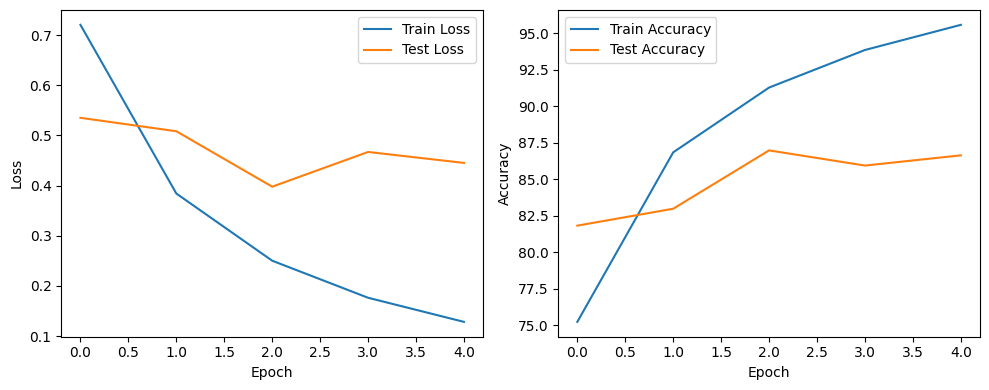

In [37]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.8658241010660086


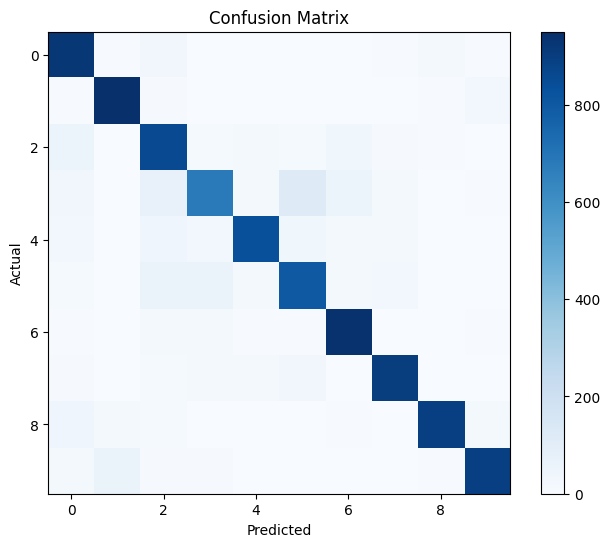

In [38]:
f1, cm = compute_f1_score(model_pretrained1, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Modification 2

- Replaced the **single `7×7` conv** with **two sequential `3×3` convolutions** to refine feature extraction.  
- **Kept maxpool** (`2×2`, stride `2`) to retain some downsampling for deeper layers.  
- This allows the model to **extract fine-grained features** while still benefiting from pretrained weights in deeper layers.  

In [ ]:
model_pretrained2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_pretrained2.conv1 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False)
)
model_pretrained2.maxpool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

num_classes = 10
model_pretrained2.fc = nn.Linear(model_pretrained2.fc.in_features, num_classes)
train_losses, test_losses, train_accuracies, test_accuracies, model_pretrained2 = train_model("pretrained_modification_2","pretrainedmodification2",model_pretrained2, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_175214-euez27mu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pretrainedmodification2
wandb: ⭐️ View project at https://wandb.ai/shravya1051/pretrained_modification_2
wandb: 🚀 View run at https://wandb.ai/shravya1051/pretrained_modification_2/runs/euez27mu


Epoch [1/5], Loss: 0.9262, Accuracy: 67.57%
Test Loss: 0.7556, Test Accuracy: 74.83%
Epoch [2/5], Loss: 0.5385, Accuracy: 81.52%
Test Loss: 0.6650, Test Accuracy: 77.40%
Epoch [3/5], Loss: 0.3743, Accuracy: 87.28%
Test Loss: 0.5328, Test Accuracy: 81.79%
Epoch [4/5], Loss: 0.2702, Accuracy: 90.60%
Test Loss: 0.5481, Test Accuracy: 82.61%
Epoch [5/5], Loss: 0.1940, Accuracy: 93.47%
Test Loss: 0.6117, Test Accuracy: 81.78%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▃▇█▇
wandb:  Test_loss █▅▁▁▃
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 81.78
wandb:  Test_loss 0.61166
wandb:  Train_acc 93.466
wandb: Train_loss 0.19403
wandb: 
wandb: 🚀 View run pretrainedmodification2 at: https://wandb.ai/shravya1051/pretrained_modification_2/runs/euez27mu
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/pretrained_modification_2
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_175214-euez27mu/logs


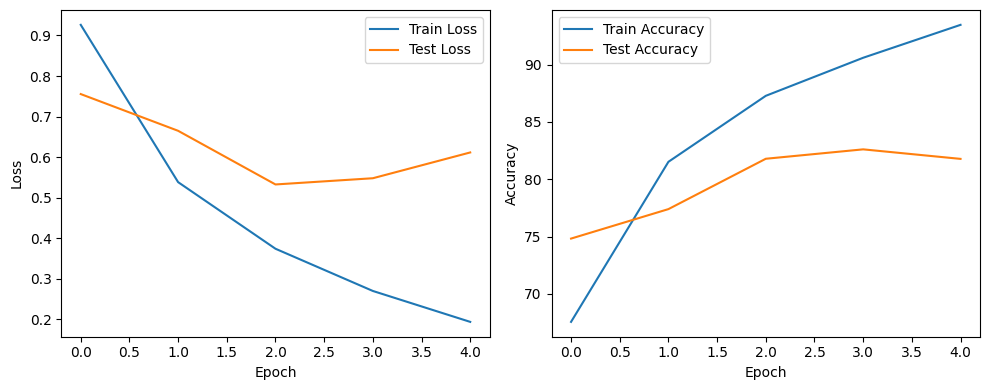

In [40]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.8176340812124282


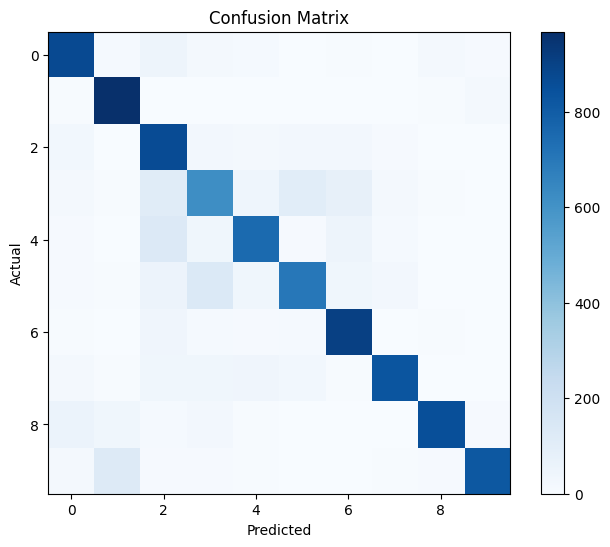

In [41]:
f1, cm = compute_f1_score(model_pretrained2, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Modification 3

- **Replaced `conv1`** with a **depthwise `3×3` convolution** (per-channel processing) followed by a **pointwise `1×1` convolution** (channel mixing).  
- **Kept maxpool** to ensure structured downsampling.  
- Depthwise separable convolutions **reduce computational cost** while still **leveraging pretrained features**, making it a more efficient alternative for small images.  

In [ ]:
model_pretrained3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_pretrained3.conv1 = nn.Sequential(
    nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1, groups=3, bias=False),
    nn.Conv2d(3, 64, kernel_size=1, bias=False)

model_pretrained3.maxpool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
num_classes = 10
model_pretrained3.fc = nn.Linear(model_pretrained3.fc.in_features, num_classes)
train_losses, test_losses, train_accuracies, test_accuracies, model_pretrained3 = train_model("pretrained_modification_3","pretrainedmodification3",model_pretrained3, train_loader, test_loader, num_epochs=5, learning_rate=0.001)

wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250209_175345-4bpeg032
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pretrainedmodification3
wandb: ⭐️ View project at https://wandb.ai/shravya1051/pretrained_modification_3
wandb: 🚀 View run at https://wandb.ai/shravya1051/pretrained_modification_3/runs/4bpeg032


Epoch [1/5], Loss: 1.0056, Accuracy: 64.71%
Test Loss: 0.8847, Test Accuracy: 70.40%
Epoch [2/5], Loss: 0.5982, Accuracy: 79.33%
Test Loss: 0.6770, Test Accuracy: 77.45%
Epoch [3/5], Loss: 0.4253, Accuracy: 85.20%
Test Loss: 0.5941, Test Accuracy: 80.10%
Epoch [4/5], Loss: 0.3072, Accuracy: 89.35%
Test Loss: 0.6913, Test Accuracy: 79.49%
Epoch [5/5], Loss: 0.2232, Accuracy: 92.36%
Test Loss: 0.7270, Test Accuracy: 78.85%


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:      Epoch ▁▃▅▆█
wandb:   Test_acc ▁▆██▇
wandb:  Test_loss █▃▁▃▄
wandb:  Train_acc ▁▅▆▇█
wandb: Train_loss █▄▃▂▁
wandb: 
wandb: Run summary:
wandb:      Epoch 5
wandb:   Test_acc 78.85
wandb:  Test_loss 0.72696
wandb:  Train_acc 92.362
wandb: Train_loss 0.22316
wandb: 
wandb: 🚀 View run pretrainedmodification3 at: https://wandb.ai/shravya1051/pretrained_modification_3/runs/4bpeg032
wandb: ⭐️ View project at: https://wandb.ai/shravya1051/pretrained_modification_3
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20250209_175345-4bpeg032/logs


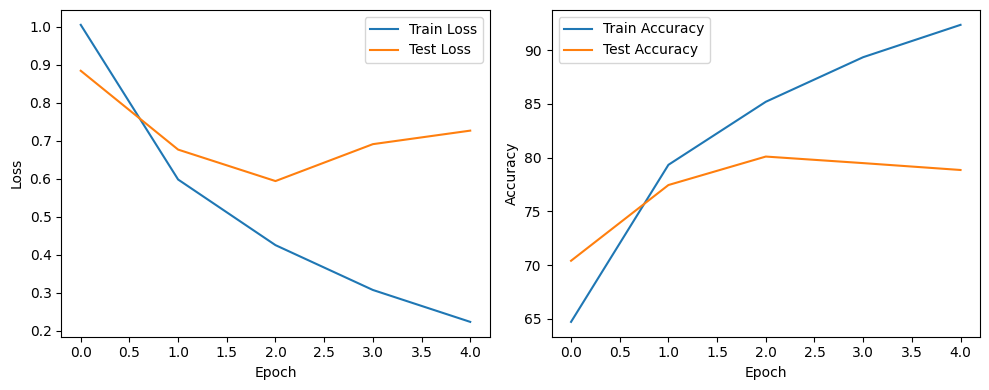

In [43]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 0.7877959187537343


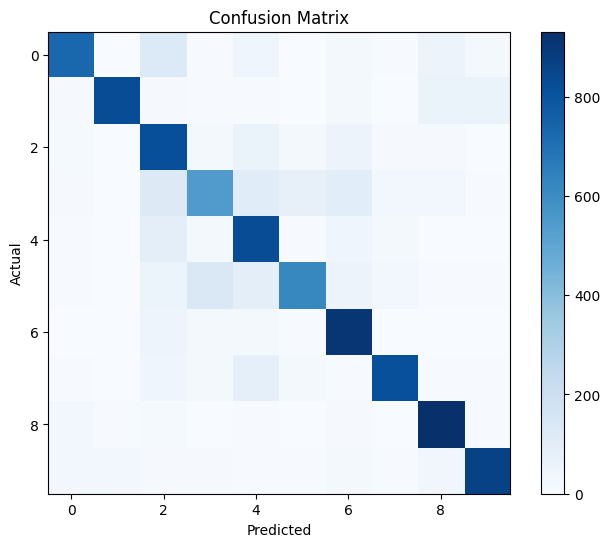

In [44]:
f1, cm = compute_f1_score(model_pretrained3, test_loader)
print(f"F1 Score: {f1}")
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

| **Model**                          | **Input Size** | **F1 Score**        |
|------------------------------------|----------------|---------------------|
| **Pretrained ResNet18 - 224×224**  | 224×224        | 0.8873              |
| **Pretrained Modification 1**      | 36×36          | 0.8658              |
| **Pretrained Modification 2**      | 36×36          | 0.8176              |
| **Pretrained Modification 3**      | 36×36          | 0.7878              |

- **Modification 1** achieved the best performance (**F1 = 0.8658**) among the 36×36 models, coming **very close** to the **224×224 pretrained model (0.8873)**. This suggests that **removing maxpool and reducing `conv1` stride** effectively retains more spatial details for small images.  
- **Modification 2** performed slightly worse (**F1 = 0.8176**), indicating that **replacing `conv1` with two `3×3` convolutions** helps but does not generalize as well as Modification 1.  
- **Modification 3** had the lowest F1 score (**0.7878**), showing that **depthwise separable convolutions** reduced computational cost but at the expense of feature richness, as pretrained weights rely on standard convolutions.  
- Overall, **modifying ResNet18 for 36×36 images improved performance significantly over the original pretrained model on 36×36**, closing the gap with **224×224 training while using less memory and compute.**  

### **Does Initializing `conv1` from Scratch Affect Training in a Pretrained Model?**  

From the results, **Modification 1** (reducing `conv1` stride and removing maxpool) achieved an **F1 score of 0.8658**, which is **very close** to the pretrained model trained on **224×224 images (0.8873)**. This suggests that initializing **only the first layer (`conv1`) from scratch** does **not significantly degrade performance**, as the deeper layers retain useful pretrained features.  

However, **Modifications 2 and 3**, which introduced more drastic changes to `conv1`, resulted in lower F1 scores (**0.8176 and 0.7878** respectively). This indicates that while the model can still learn effectively, modifying `conv1` too aggressively (such as using depthwise separable convolutions) may reduce performance, likely due to differences in feature extraction compared to the pretrained weights.  

Overall, initializing `conv1` from scratch while keeping the rest of the pretrained model **does not severely harm learning**, as long as the new layer aligns well with the feature extraction needs of the model. However, excessive changes can reduce the effectiveness of pretrained knowledge, as seen in **Modification 3**.  


## **Comparison of All Trained Models**  

| **Model**                              | **Pretrained** | **Input Size** | **F1 Score** | **Key Modifications** |
|----------------------------------------|--------------|----------------|--------------|-----------------------|
| **ResNet18 (Scratch)**                 |  No       | 36×36          | 0.7469       | Default ResNet18 |
| **Pretrained ResNet18**                |  Yes      | 36×36          | 0.7996       | Default ResNet18 |
| **ResNet18 (Scratch)**                 |  No       | 224×224        | 0.7518       | Default ResNet18 |
| **Pretrained ResNet18**                |  Yes      | 224×224        | 0.8873       | Default ResNet18 |
| **Scratch Modification 1**             |  No       | 36×36          | 0.8213       | Reduced `conv1` stride, removed maxpool |
| **Scratch Modification 2**             |  No       | 36×36          | 0.7743       | Used `5×5` kernel instead of `7×7` |
| **Scratch Modification 3**             |  No       | 36×36          | 0.7743       | Replaced `conv1` with two `3×3` convolutions |
| **Pretrained Modification 1**          |  Yes      | 36×36          | 0.8658       | Reduced `conv1` stride, removed maxpool |
| **Pretrained Modification 2**          |  Yes      | 36×36          | 0.8176       | Replaced `conv1` with two `3×3` convolutions |
| **Pretrained Modification 3**          |  Yes      | 36×36          | 0.7878       | Used depthwise separable convolutions |

---

## **Comparisons**  

1. **Pretrained vs. Non-Pretrained Models**  
   - **Pretrained models consistently perform better** than their non-pretrained counterparts.  
   - For **36×36 input**, the **pretrained model achieved 0.7996 F1**, outperforming **scratch-trained ResNet18 (0.7469 F1)** due to knowledge transfer from ImageNet.  
   - For **224×224 input**, the pretrained model scored **0.8873 F1**, a large improvement over scratch (**0.7518 F1**), showing that pretrained models work best when used at their expected input size.  

2. **Effect of Image Size (36×36 vs. 224×224)**  
   - Training on **224×224 images gives the highest F1 scores**, but **requires more memory and longer training time**.  
   - **Modification 1 (Pretrained, 36×36)** achieved **0.8658 F1**, which is close to **224×224’s 0.8873**, suggesting that **careful architecture changes can make smaller images nearly as effective**.  
   - Using **small images (36×36) without modifications leads to worse performance**, as seen with **scratch-trained ResNet18 (0.7469 F1)**.  

3. **Effect of Kernel Size & Conv1 Modifications**  
   - **Modification 1 (Reduced Stride, No MaxPool)** was the most effective (F1 **0.8658 for pretrained**, **0.8213 for scratch**). This shows that **preserving spatial details early in the network helps small images retain more useful features**.  
   - **Modification 2 (`5×5` Kernel, Two `3×3` Convs)** slightly improved over the default 36×36 model but was **less effective than Modification 1**, showing that **changing the kernel size alone is not enough**.  
   - **Modification 3 (Depthwise Separable Convolutions) performed the worst**, likely because pretrained weights rely on standard convolutions, and depthwise convolutions disrupt feature learning.  

---

## **Why Do These Differences Arise?**  

1. **Pretrained Models Learn Better Representations**  
   - Pretrained models **already contain learned features from ImageNet**, so they require **less training data** and adapt better even with small images.  
   - Scratch-trained models struggle because they **start with random weights** and need more data to generalize well.  

2. **Smaller Images Lose Information Faster**  
   - **36×36 images undergo aggressive downsampling** in the first layers, reducing feature quality early in the network.  
   - **Modifying `conv1` (smaller kernel, lower stride, no maxpool) helped significantly** because it prevented excessive information loss.  

3. **224×224 Models Benefit from Larger Receptive Fields**  
   - Larger images allow **deeper layers to capture long-range dependencies** better.  
   - However, the **best 36×36 modifications nearly matched 224×224 performance**, showing that **careful architectural changes can compensate for smaller input sizes**.  

---

### **Conclusion**
- **Pretrained models outperform scratch models in all cases.**  
- **224×224 inputs give the highest F1 scores** but require more computation.  
- **Modification 1 (Lower Stride, No MaxPool) was the best for 36×36**, showing that **preserving spatial details is crucial for small images**.  
- **Depthwise separable convolutions hurt performance in pretrained models**, likely because they disrupt feature extraction learned from ImageNet.  
